# Fase 1: Tarea 3 y 4 Machine Learning II

## Autores
| Nombres | Correos | 
|----------|----------|
| Julio Lucero   | julio.lucero@alumnos.upm.es  | 
| x   | x  | 
|  x | x | 


## Importamos Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score

## Carga de los datos y Exploracion

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test-unlabelled.csv')

print(f"Dimensiones del dataset de entrenamiento: {train_df.shape}")
print(f"Dimensiones del dataset de prueba: {test_df.shape}\n")

# Verificamos si hay valores nulos
nulos = train_df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos detectados.")

X_train = train_df.drop('class', axis=1)
y_train = train_df['class']

Dimensiones del dataset de entrenamiento: (1000, 610)
Dimensiones del dataset de prueba: (2000, 610)

No hay valores nulos detectados.


## Preprocesamos, escalamos estandarizando los datos y aplicamos Wrapper para naive bayes

In [6]:
# Definimos el estimador base para Naive Bayes
gnb = GaussianNB()

sfs = SequentialFeatureSelector(gnb, n_features_to_select=20, direction='forward', cv=5, n_jobs=-1)

naive_bayes_wrapper_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', sfs), 
    ('classifier', gnb)
])

# PIPELINE RANDOM FOREST (Lo mantenemos igual, no necesita wrapper)
random_forest_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

## Entrenamiento con Naive Bayes

In [7]:
# Entrenamos el pipeline completo
naive_bayes_wrapper_pipeline.fit(X_train, y_train)

# Calculamos 5-fold Cross Validation con el pipeline
nb_cv_scores = cross_val_score(naive_bayes_wrapper_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Calculamos la precisión en entrenamiento
nb_train_acc = accuracy_score(y_train, naive_bayes_wrapper_pipeline.predict(X_train))

## Resultado de Naive Bayes con wrapper

In [8]:
# Extraemos qué características sobrevivieron al Wrapper
features_seleccionadas = naive_bayes_wrapper_pipeline.named_steps['feature_selection'].get_support()
n_features_elegidas = features_seleccionadas.sum()
columnas_elegidas = X_train.columns[features_seleccionadas].tolist()

print(f"Precisión en Entrenamiento (Train Accuracy): {nb_train_acc:.4f}")
print(f"Precisión 5-Fold CV: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")
print(f"\nEl Wrapper redujo de {X_train.shape[1]} a {n_features_elegidas} características.")
print(f"Variables conservadas: {columnas_elegidas}") # Descomenta esto si quieres ver los nombres exactos en pantalla

Precisión en Entrenamiento (Train Accuracy): 0.6970
Precisión 5-Fold CV: 0.6540 (+/- 0.0637)

El Wrapper redujo de 609 a 20 características.
Variables conservadas: ['jvbioam', 'ylcgdnd', 'kuzsfrc', 'egshhmq', 'ltpbwwt', 'yanyfsa', 'eadsvll', 'sriualw', 'tsxajlt', 'cacwddh', 'wawgdcs', 'ycyyjjd', 'biorynj', 'gztxoti', 'jafsbde', 'mmocwnw', 'jcpenza', 'bnpymuf', 'rdnxplm', 'tuobnus']


## Entrenamiento con Random Forest

In [5]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],        
    'classifier__max_depth': [5, 8, 12, 15],             
    'classifier__min_samples_split': [5, 10, 20],        
    'classifier__min_samples_leaf': [2, 5, 10],          
    'classifier__max_features': ['sqrt', 0.5]            
}

random_forest_grid = GridSearchCV(random_forest_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
random_forest_grid.fit(X_train, y_train)

best_rf = random_forest_grid.best_estimator_
rf_train_acc = accuracy_score(y_train, best_rf.predict(X_train))

print(f"Mejores parámetros encontrados: {random_forest_grid.best_params_}")
print(f"Precisión en Entrenamiento (Train Accuracy): {rf_train_acc:.4f}")
print(f"Precisión 5-Fold CV (Mejor Modelo): {random_forest_grid.best_score_:.4f}")

Mejores parámetros encontrados: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Precisión en Entrenamiento (Train Accuracy): 0.9700
Precisión 5-Fold CV (Mejor Modelo): 0.8270


## Importancia de caracteristicas en Random Forest

     Feature  Importance
98   yanyfsa    0.029518
281  vzyjlbt    0.024946
382  jafsbde    0.024815
236  mwvshcy    0.019883
465  bffqymv    0.018610
134  qmkchdk    0.018278
520  plcvrqv    0.016560
392  qydpedv    0.015686
150  eadsvll    0.015392
50   pmvpzze    0.014939


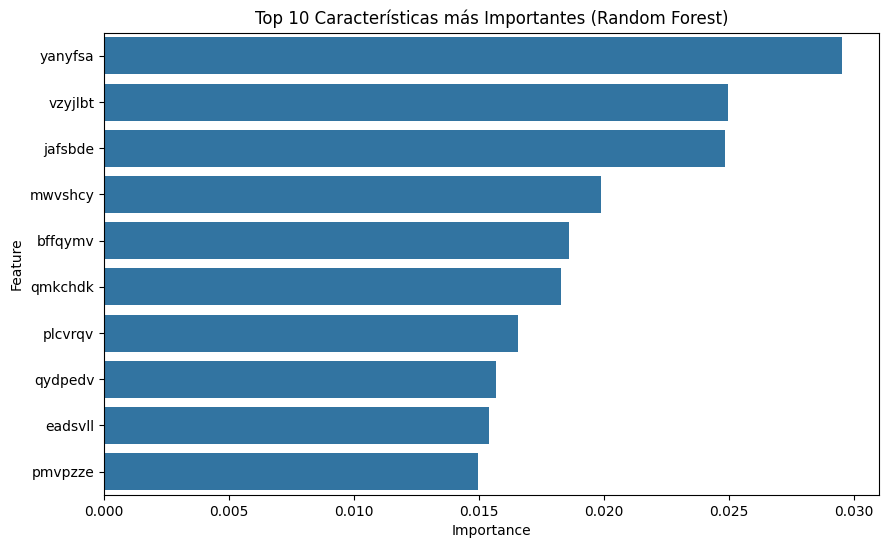

In [6]:
random_forest_model = best_rf.named_steps['classifier']
importances = random_forest_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10)) 

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Características más Importantes (Random Forest)')
plt.show()

## Testear el modelo prediciendo con random forest

In [ ]:
test_df = pd.read_csv('test-unlabelled.csv')

X_test_final = test_df.drop('class', axis=1)

predicciones_finales = best_rf.predict(X_test_final)

test_df['class'] = predicciones_finales

test_df.to_csv('test_predictions_randoforest.csv', index=False)

print("\nPrimeras 5 filas con la columna 'class' ya rellenada:")
print(test_df[['class']].head()) # Mostramos solo la columna de clase para verificar

¡Predicciones generadas con éxito y guardadas en 'test_predictions_randoforest.csv'!

Primeras 5 filas con la columna 'class' ya rellenada:
  class
0     A
1     A
2     B
3     B
4     C


## Testeando el modelo prediciendo con naive bayes

In [9]:
test_df_nb = pd.read_csv('test-unlabelled.csv')

X_test_final_nb = test_df_nb.drop('class', axis=1)

predicciones_nb = naive_bayes_wrapper_pipeline.predict(X_test_final_nb)

test_df_nb['class'] = predicciones_nb

test_df_nb.to_csv('test_predictions_NaiveBayes.csv', index=False)

print("\nPrimeras 5 filas con la columna 'class' ya rellenada (Naive Bayes):")
print(test_df_nb[['class']].head())


Primeras 5 filas con la columna 'class' ya rellenada (Naive Bayes):
  class
0     A
1     A
2     B
3     B
4     A


## Naive Bayes - Lama: Multivariate Correlation Filter + ANOVA

In [4]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        return self
    def transform(self, X):
        return pd.DataFrame(X).drop(columns=self.to_drop_).values

nb_lama_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('corr_filter', CorrelationFilter(threshold=0.9)),
    ('anova', SelectKBest(score_func=f_classif, k=10)),
    ('classifier', GaussianNB())
])

nb_lama_pipeline.fit(X_train, y_train)
nb_lama_cv = cross_val_score(nb_lama_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
nb_lama_train = accuracy_score(y_train, nb_lama_pipeline.predict(X_train))

print(f"Train Accuracy: {nb_lama_train:.4f}")
print(f"5-Fold CV: {nb_lama_cv.mean():.4f} (+/- {nb_lama_cv.std()*2:.4f})")

Train Accuracy: 0.6390
5-Fold CV: 0.6400 (+/- 0.0544)


## Random Forest - Lama: Correlation Filter + RandomizedSearchCV

In [5]:
rf_lama_pipeline = Pipeline([
    ('corr_filter', CorrelationFilter(threshold=0.9)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [8, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__max_features': ['sqrt', 0.3, 0.5]
}

rf_random_search = RandomizedSearchCV(
    rf_lama_pipeline, param_dist, n_iter=15, cv=5,
    scoring='accuracy', n_jobs=-1, random_state=42
)
rf_random_search.fit(X_train, y_train)

best_rf_lama = rf_random_search.best_estimator_
rf_lama_train = accuracy_score(y_train, best_rf_lama.predict(X_train))

print(f"Best Parameters: {rf_random_search.best_params_}")
print(f"Train Accuracy: {rf_lama_train:.4f}")
print(f"5-Fold CV: {rf_random_search.best_score_:.4f}")

Best Parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15}
Train Accuracy: 1.0000
5-Fold CV: 0.8260
